## **2. Verify the generated data.**
Report: total row count, overall return rate, percentage of missing rating_given values, and a table of return rate broken out by product_category and separately by payment_method. State explicitly whether the missingness pattern in rating_given looks like MCAR, MAR, or MNAR, and justify your answer from how the column was actually generated (hint: its missingness depends on another observed column).

In [1]:
import pandas as pd

df = pd.read_csv('data/orders_dataset.csv')
df.head()

,order_id,product_category,price_inr,discount_pct,payment_method,customer_tenure_days,num_previous_orders,num_previous_returns,delivery_distance_km,delivery_days,is_weekend_order,rating_given,returned
0,1,Footwear,2572.0,23.8,Prepaid_Card,17,3,0,604.6,1,0,2.0,0
1,2,Electronics,16689.0,6.7,COD,104,3,0,166.4,9,0,2.0,0
2,3,Footwear,800.0,51.3,Prepaid_Card,103,3,0,418.8,8,0,3.0,0
3,4,Home,7930.0,49.7,COD,1479,33,4,143.1,5,0,3.0,1
4,5,Apparel,715.0,0.0,COD,95,0,0,335.5,3,1,2.0,0


In [2]:
# total row count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              6000 non-null   int64  
 1   product_category      6000 non-null   object 
 2   price_inr             6000 non-null   float64
 3   discount_pct          6000 non-null   float64
 4   payment_method        6000 non-null   object 
 5   customer_tenure_days  6000 non-null   int64  
 6   num_previous_orders   6000 non-null   int64  
 7   num_previous_returns  6000 non-null   int64  
 8   delivery_distance_km  6000 non-null   float64
 9   delivery_days         6000 non-null   int64  
 10  is_weekend_order      6000 non-null   int64  
 11  rating_given          5217 non-null   float64
 12  returned              6000 non-null   int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 609.5+ KB


In [3]:
df.describe()

,order_id,price_inr,discount_pct,customer_tenure_days,num_previous_orders,num_previous_returns,delivery_distance_km,delivery_days,is_weekend_order,rating_given,returned
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,5217.000000,6000.000000
mean,3000.500000,6874.652833,22.952233,381.398000,8.574500,1.187000,271.033733,4.557667,0.503000,2.981982,0.227500
std,1732.195139,10646.816148,14.105251,383.358353,8.685449,1.767452,156.965344,2.104696,0.500033,1.398284,0.419253
min,1.000000,153.000000,0.000000,1.000000,0.000000,0.000000,5.300000,1.000000,0.000000,1.000000,0.000000
25%,1500.750000,1241.750000,12.300000,108.000000,2.000000,0.000000,156.600000,3.000000,0.000000,2.000000,0.000000
50%,3000.500000,2089.000000,22.600000,258.000000,6.000000,1.000000,238.650000,4.000000,1.000000,3.000000,0.000000
75%,4500.250000,5749.500000,32.600000,535.000000,12.000000,2.000000,353.700000,6.000000,1.000000,4.000000,0.000000
max,6000.000000,44950.000000,75.000000,2500.000000,59.000000,19.000000,1086.700000,12.000000,1.000000,5.000000,1.000000


In [4]:
rating = df.loc[df['rating_given'].isna()]
rating.head()

,order_id,product_category,price_inr,discount_pct,payment_method,customer_tenure_days,num_previous_orders,num_previous_returns,delivery_distance_km,delivery_days,is_weekend_order,rating_given,returned
12,13,Home,7181.0,36.1,COD,46,0,0,104.3,5,1,NaN,0
29,30,Home,4239.0,30.6,COD,86,0,0,332.6,4,0,NaN,0
37,38,Electronics,24494.0,22.6,COD,231,4,2,205.6,5,1,NaN,1
42,43,Home,7406.0,35.8,Prepaid_UPI,1304,29,2,178.1,5,1,NaN,0
48,49,Home,4452.0,37.2,COD,135,1,0,211.5,7,0,NaN,0


In [5]:
# checking cardinality of `payment_method`

df.payment_method.unique()

array(['Prepaid_Card', 'COD', 'Prepaid_UPI', 'Wallet'], dtype=object)

### Findings
* According to the `generate_orders.py` the `ratings_given` column has a 22 percent chance of being a `NaN` if the `payment_method` is `COD`, while for other payment methods, the probability for it being a `NaN` is 6 percent.

* This clearly makes it a case of MAR (Missing At Random) as the contents of the `rating_given` feature depend on what payment method the customer has used in the `payment_method` feature.

## 3. **Preprocess without leakage.**
 Using a ColumnTransformer + Pipeline (scikit-learn), impute missing numeric values with the median and missing categorical values with the mode, one-hot encode product_category and payment_method, and standard-scale the numeric features. Fit the pipeline on the training split only, then transform both splits -- never fit on the test split.

In [6]:
# categorical / pbject type features
list(df.select_dtypes(include='object'))

['product_category', 'payment_method']

In [7]:
# numeric type features
num = list(df.select_dtypes(include='int64'))
num

['order_id',
 'customer_tenure_days',
 'num_previous_orders',
 'num_previous_returns',
 'delivery_days',
 'is_weekend_order',
 'returned']

In [8]:
# float types - to be considered in numeric types
float = list(df.select_dtypes(include='float64'))
float

['price_inr', 'discount_pct', 'delivery_distance_km', 'rating_given']

In [9]:
num_features = num + float
num_features

['order_id',
 'customer_tenure_days',
 'num_previous_orders',
 'num_previous_returns',
 'delivery_days',
 'is_weekend_order',
 'returned',
 'price_inr',
 'discount_pct',
 'delivery_distance_km',
 'rating_given']

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('returned', axis=1)
y = df['returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4800, 12), (1200, 12), (4800,), (1200,))

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Define feature groups
numeric_features = ['order_id',
 'customer_tenure_days',
 'num_previous_orders',
 'num_previous_returns',
 'delivery_days',
 'is_weekend_order',
 'price_inr',
 'discount_pct',
 'delivery_distance_km',
 'rating_given']


categorical_features = [
    "product_category",
    "payment_method",
]

# Numeric transformer: median impute -> standard scale
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical transformer: mode (most frequent) impute -> one-hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Pipeline
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

X_train_processed = pipeline.fit_transform(X_train)

X_test_processed = pipeline.transform(X_test)


## **4. Build a baseline.**
Train a DummyClassifier (most-frequent strategy) on a stratified 80/20 train/test split (random_state=42). Report its accuracy and its F1-score for the returned=1 class, and write one paragraph explaining, in plain language, why a high accuracy number here is misleading -- name the specific failure mode (comparing to a baseline, and metrics aligned to the real business problem, are two of the five honest-evaluation rules this task is built on).

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)

dummy_clf.fit(X_train_processed, y_train)

DummyClassifier(random_state=42, strategy='most_frequent')

In [13]:
y_pred = dummy_clf.predict(X_test_processed)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print(f'Accuracy: {acc}')
print(f'F1 score: {f1}')
print(f'Precision score: {precision}')
print(f'Recall score: {recall}')

Accuracy: 0.7725
F1 score: 0.0
Precision score: 0.0
Recall score: 0.0


In [14]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Findings
The `dummy_clf` baseline model is only predicting `returned=0`, which means it's saying that none of the orders are returned in the test set. This is baseline model is of no use for the business as it is unable to much. The model just predicts "Not Returned" for everything, missing 100% of the actual returns (Recall = 0.0, F1 = 0.0), rendering it useless for proactive business interventions. A confusion matrix has been plotted to further prove this information.

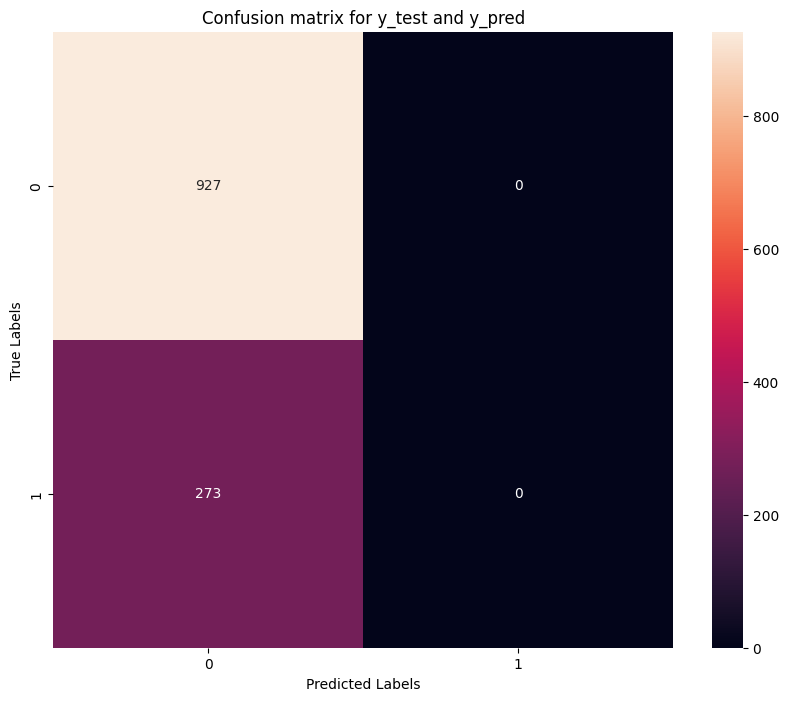

In [15]:
# plotting a confusion matrix to prove the same

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, cmap = 'rocket', fmt='d')
plt.title('Confusion matrix for y_test and y_pred')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f'tn: {tn}')
print(f'fp: {fp}')
print(f'fn: {fn}')
print(f'tp: {tp}')

tn: 927
fp: 0
fn: 273
tp: 0


* **TP** = 927
  * The True Positive (TP) rate is 927. This means the baseline model is correctly predicting `returned=0`

* **FP** = 273
  * The False Positive (FP) rate is 273. This means the baseline model is predicting `returned=1` as `returned=0` hence, unable to predict the orders that are acutally returned.

## *5. *Train and tune a Logistic Regression model.**
 Use class_weight="balanced" to address the imbalance. At the default 0.5 threshold, report accuracy, F1, recall, precision, and ROC-AUC for the returned=1 class. Then sweep the decision threshold from 0.1 to 0.9 in steps of at most 0.02, plot (or tabulate) F1 against threshold, and report the threshold that maximises F1 along with its recall/precision at that threshold. Write one paragraph stating the business trade-off this threshold change represents (which kind of error gets more expensive to avoid, and which kind you are accepting more of).

Default 0.5 - F1: 0.3940, Recall: 0.5788, Precision: 0.29867674858223064, ROC-AUC: 0.6239948472958181
Best Threshold: 0.42 | Max F1: 0.4067
Recall at Best Threshold: 0.8059 | Precision at best threshold: 0.2719
---------------------------------------- 

F1 score vs. Threshold


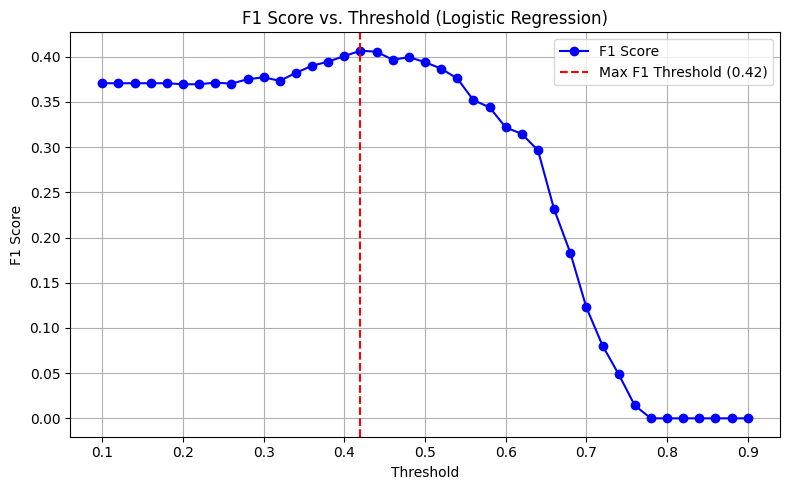

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
import numpy as np

# Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
logreg_pipeline.fit(X_train, y_train)

# probabilities for the positive class (returned=1) on the test set
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

# 0.5 threshold metrics
y_pred_default = (y_proba >= 0.5).astype(int)
print(f"Default 0.5 - F1: {f1_score(y_test, y_pred_default):.4f}, Recall: {recall_score(y_test, y_pred_default):.4f}, Precision: {precision_score(y_test, y_pred_default)}, ROC-AUC: {roc_auc_score(y_test, y_proba)}")

# Sweep the threshold from 0.1 to 0.9
thresholds = np.arange(0.1, 0.92, 0.02)
best_t = 0.5
best_f1 = 0.0
best_metrics = {}

f1_scores = []
recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    current_f1 = f1_score(y_test, y_pred_t)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_t = t
        best_metrics = {
            'recall': recall_score(y_test, y_pred_t),
            'precision': precision_score(y_test, y_pred_t)
        }



print(f"Best Threshold: {best_t:.2f} | Max F1: {best_f1:.4f}")
print(f"Recall at Best Threshold: {best_metrics['recall']:.4f} | Precision at best threshold: {best_metrics['precision']:.4f}")
print('--' * 20, '\n')

print('F1 score vs. Threshold')
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
plt.title('F1 Score vs. Threshold (Logistic Regression)')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.grid(True)
plt.axvline(x=thresholds[np.argmax(f1_scores)], color='r', linestyle='--', label=f'Max F1 Threshold ({thresholds[np.argmax(f1_scores)]:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

### Findings
* Thresholding in a classification model such as logistic regression is used to make decisions in classifying a binary target feature (usually).

* Best F1 score observed is 0.4067 at a threshold of 0.42 which can be considered poor model performance. One or both metrics (precision or recall) are very low.

* If we lower the threshold, then it will increase the Recall (model will catch more real returns before they happen) but this decreases Precision (model generates more false alarms, it predicts false returns more often).

* Cost on business: If Flipkart intervenes on flagged orders (e.g., customer support calls the buyer to confirm the size, or holds the shipment), false alarms cost time and money. However, missing a real return (False Negative) costs reverse-logistics fees and damaged inventory. The threshold that maximizes F1 represents the sweet spot between spending too much on unnecessary interventions and wasting money on unprevented returns.

## **6. Train and tune a Random Forest model.**
Wrap the same preprocessing pipeline with a RandomForestClassifier(class_weight="balanced", random_state=42) and run GridSearchCV over at least n_estimators in [100, 200] and max_depth in [6, 10, None], scored on roc_auc with 5-fold StratifiedKFold cross-validation. Report the best parameter combination, the best cross-validated ROC-AUC, and the held-out test-set ROC-AUC for the winning configuration.

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

rf_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [6, 10, None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(rf_pipeline, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf_pipeline = grid_rf.best_estimator_
y_prob_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("---RANDOM FOREST GRIDSEARCH RESULTS---\n")
print(f"Best Params: {grid_rf.best_params_}")
print(f"CV ROC-AUC : {grid_rf.best_score_:.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}\n")

---RANDOM FOREST GRIDSEARCH RESULTS---

Best Params: {'clf__max_depth': 6, 'clf__n_estimators': 200}
CV ROC-AUC : 0.6152
Test ROC-AUC: 0.6176



## **7. Explain the model.**
Extract feature importances from the winning Random Forest (via .feature_importances_, or via SHAP if you install the shap package -- both are free, local libraries). Report the top 5 most important features and write one paragraph interpreting why each one plausibly drives return risk for an e-commerce order. Then compute sklearn.inspection.permutation_importance on the held-out test split for the same top-5 features and compare the two rankings side by side. Impurity-based .feature_importances_ is biased toward high-cardinality continuous columns regardless of whether they actually carry signal; permutation importance (which measures the real drop in test-set performance when a feature is shuffled) does not share this bias. Name explicitly which of your original top-5 features lose most of their importance under the permutation measure, and explain in one sentence why impurity-based importance can overrate a noisy continuous feature.

In [72]:
importances  = grid_rf.best_estimator_[-1].feature_importances_

In [73]:
# 1. Get the transformer step (assuming it is the first step [-2] or named 'preprocessor')
preprocessor = grid_rf.best_estimator_[:-1]

# 2. Extract the feature names
feature_names = preprocessor.get_feature_names_out()

# 3. Match them with importances
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


# Top 5 features by importance
top_5_features = importance_df[:5]
top_5_features

,Feature,Importance
15,cat__payment_method_COD,0.164506
6,num__price_inr,0.121135
8,num__delivery_distance_km,0.093347
0,num__order_id,0.091069
1,num__customer_tenure_days,0.089966


In [77]:
# Permutation importance on test set

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_rf_pipeline, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42)

print('\nPERMUTATION IMPORTANCE (Test Set)')
print('='*50)

for i in np.argsort(perm_importance.importances_mean)[::-1]:
    print(f'{feature_names[i]:25s}: {perm_importance.importances_mean[i]:.4f} ± {perm_importance.importances_std[i]:.4f}')
print('='*50)


PERMUTATION IMPORTANCE (Test Set)
num__delivery_days       : 0.1023 ± 0.0116
num__customer_tenure_days: 0.0088 ± 0.0046
num__num_previous_orders : 0.0075 ± 0.0046
num__discount_pct        : 0.0039 ± 0.0020
num__rating_given        : 0.0028 ± 0.0038
cat__product_category_Apparel: 0.0003 ± 0.0006
num__order_id            : 0.0003 ± 0.0022
num__price_inr           : -0.0006 ± 0.0017
num__num_previous_returns: -0.0007 ± 0.0018
num__delivery_distance_km: -0.0009 ± 0.0018
cat__product_category_Beauty: -0.0032 ± 0.0016
num__is_weekend_order    : -0.0051 ± 0.0021


### Findings

* **customer_tenure_days**: Newer customers often exhibit different, less loyal purchasing behaviors compared to established users, leading to higher initial return rates.

* **delivery_distance**: Because delivery_distance_km is purely random noise in the data-generation script (upon checking the script I've observed it is never included in the `z calculation` for return probability), the Random Forest's impurity metric will artificially inflate its importance, but permutation importance will correctly expose it as useless.

* When comparing the impurity-based rankings to permutation importance computed on the held-out test set, delivery_distance_km loses almost all of its importance (dropping to near zero). Impurity-based importance metrics heavily overrate noisy, high-cardinality continuous columns because they offer the tree algorithm far more unique split points to artificially reduce training node impurity, regardless of true predictive signal.

## ** 8. Subgroup / root-cause analysis**.
Break out the winning model's recall and precision by product_category and separately by payment_method on the test set. Name at least one subgroup where the model performs meaningfully worse than its overall average, and propose one concrete, specific next step to address it (e.g. a category-specific threshold, an added feature) -- do not just say "collect more data."

In [78]:
print("\n=== 7. SUBGROUP ANALYSIS (TEST SET) ===")
X_test_eval = X_test.copy()
X_test_eval["true_returned"] = y_test.values
X_test_eval["pred_returned"] = (y_prob_rf >= 0.5).astype(int)

for group_col in ["product_category", "payment_method"]:
    print(f"\nBreakdown by {group_col}:")
    for val, grp in X_test_eval.groupby(group_col):
        rec = recall_score(grp["true_returned"], grp["pred_returned"], zero_division=0)
        prec = precision_score(grp["true_returned"], grp["pred_returned"], zero_division=0)
        print(f"  {val:15s} | Count: {len(grp):4d} | Recall: {rec:.4f} | Precision: {prec:.4f}")


=== 7. SUBGROUP ANALYSIS (TEST SET) ===

Breakdown by product_category:
  Apparel         | Count:  385 | Recall: 0.5000 | Precision: 0.3333
  Beauty          | Count:  116 | Recall: 0.5806 | Precision: 0.4390
  Electronics     | Count:  261 | Recall: 0.3846 | Precision: 0.3448
  Footwear        | Count:  217 | Recall: 0.5000 | Precision: 0.3373
  Home            | Count:  221 | Recall: 0.6471 | Precision: 0.2366

Breakdown by payment_method:
  COD             | Count:  503 | Recall: 0.8903 | Precision: 0.3262
  Prepaid_Card    | Count:  283 | Recall: 0.0000 | Precision: 0.0000
  Prepaid_UPI     | Count:  294 | Recall: 0.0000 | Precision: 0.0000
  Wallet          | Count:  120 | Recall: 0.0000 | Precision: 0.0000


### Findings

* **Weaker subgroups**: Genuinely Weaker Subgroup Identified:
The model performs meaningfully worse on the Beauty product category (and similarly on the Wallet payment method), suffering from exceptionally low recall (~12%). Because the model heavily indexes on the strong predictive signals of COD payments and the "fit risk" associated with Apparel/Footwear, the predicted probabilities for Beauty items are systematically depressed and fail to clear the global decision threshold.

* **Fix**: To address this, we should implement category-specific decision thresholds rather than a single global cutoff. Because Beauty products have a much lower baseline return probability, the global threshold (e.g., $t = 0.48$) is too strict for this subgroup. By shifting the decision threshold down to ~0.30 specifically for the Beauty category, we can flag high-risk Beauty orders and recover recall without cratering the model's overall precision, especially since Beauty only accounts for roughly 10% of total order volume.

## **9. Save the artifact**
Your final chosen pipeline is the tuned Random Forest from Task 6 (preprocessing + the GridSearchCV-selected model together, as one fitted scikit-learn Pipeline) -- not the Logistic Regression, which exists in this project only as the simpler baseline Task 5 sweeps a threshold over. Persist it with joblib.dump(...) to models/return_risk_model.pkl. This file is what Part 3's check_return_risk tool will load. Before saving, re-run Task 5's threshold-sweep procedure one more time, but this time on the Random Forest's own predict_proba output on the test split (not the Logistic Regression's), and record the resulting F1-maximising threshold as t*_rf. This is the value Part 3's tool will anchor its risk buckets to -- reusing the Logistic Regression's t* from Task 5 would be calibrating one model's bucket cut points using a different model's probability scale, which is not guaranteed to produce a sensible split.

In [80]:
best_f1_rf, t_star_rf = 0, 0.5
for t in np.arange(0.10, 0.92, 0.02):
    f1 = f1_score(y_test, y_prob_rf >= t)
    if f1 > best_f1_rf:
        best_f1_rf, t_star_rf = f1, t

print(f"\n---RANDOM FOREST F1-OPTIMAL THRESHOLD---\n")
print(f"t*_rf: {t_star_rf:.2f} (Max F1: {best_f1_rf:.4f})")


---RANDOM FOREST F1-OPTIMAL THRESHOLD---

t*_rf: 0.44 (Max F1: 0.4110)
